**Аналитическая задача** -- по признаковому описанию построить портрет клиента, склонного к положительному отклику на рекламное предложение.

Предполагается, что получив такую оценку для некоторого множества клиентов, компания будет обращаться только к тем из них, которые склонны к отклику.

**Описание полей**

|Признак|Расшифровка|
|--:|:--|
| AGREEMENT_RK | уникальный идентификатор объекта в выборке |
| TARGET | целевая переменная:отклик на маркетинговую кампанию (1 - отклик был зарегистрирован, 0 - отклика не было) |
| AGE |	возраст клиента |
| SOCSTATUS_WORK_FL | социальный статус клиента относительно работы (1 - работает, 0 - не работает)|
| SOCSTATUS_PENS_FL | социальный статус клиента относительно пенсии (1 - пенсионер, 0 - не пенсионер)|
| GENDER | пол клиента |
| CHILD_TOTAL | количество детей клиента |
| DEPENDANTS | количество иждивенцев клиента
| EDUCATION | образование |
| MARITAL_STATUS | семейное положение |
| GEN_INDUSTRY | отрасль работы клиента |
| GEN_TITLE |	должность |
| ORG_TP_STATE |	форма собственности компании|
| ORG_TP_FCAPITAL |	отношение к иностранному капиталу|
| JOB_DIR |	направление деятельности внутри компании|
| FAMILY_INCOME |	семейный доход (несколько категорий)|
| PERSONAL_INCOME |	личный доход клиента (в рублях)|
| REG_ADDRESS_PROVINCE | область регистрации клиента|
| FACT_ADDRESS_PROVINCE | область фактического пребывания клиента |
| POSTAL_ADDRESS_PROVINCE |	почтовый адрес область|
| TP_PROVINCE |	область торговой точки, где клиент брал последний кредит|
| REGION_NM	| регион РФ |
| FL_PRESENCE_FL | наличие в собственности квартиры (1 - есть, 0 - нет)|
| OWN_AUTO | кол-во автомобилей в собственности|
| AUTO_RUS_FL | наличие в собственности автомобиля российского производства ( 1 - есть, 0 - нет)|
| HS_PRESENCE_FL |	наличие в собственности загородного дома (1 - есть, 0 - нет)|
| COT_PRESENCE_FL |	наличие в собственности котеджа (1 - есть, 0 - нет) |
| GAR_PRESENCE_FL |	наличие в собственности гаража (1 - есть, 0 - нет)|
| LAND_PRESENCE_FL | наличие в собственности земельного участка (1 - есть, 0 - нет)|
| FACT_LIVING_TERM | количество месяцев проживания по месту фактического пребывания |
| WORK_TIME | время работы на текущем месте (в месяцах) |
| CREDIT | сумма последнего кредита клиента (в рублях) |
| TERM | срок кредита, мес.|
| LOAN_NUM_PAYM | количество платежей, которые сделал клиент |
| LOAN_DLQ_NUM | количество просрочек, допущенных клиентом |
| LOAN_MAX_DLQ_AMT | максимальная сумма просрочки (в рублях) |
| DATE_CREDIT | дата взятия кредита |

**Примерный план по выполнению проекта**

Шаг 1. Загрузка данных;

Шаг 2. Первичная обработка данных (при необходимости):
- скорректировать заголовки;
- скорректировать типы признаков;
- проверить наличие дублирующихся записей;
- проверить наличие аномальных значений;
- восстановить пропущенные значения.

Шаг 3. Добавьте в таблицу следующие признаки:
- день недели, месяц и год взятия кредита;
- адрес регистрации и адрес фактического пребывания клиента совпадают (1 -- совпадает, 0 -- не совпадает);
- адрес фактического пребывания клиента и его почтовый адрес совпадают(1 -- совпадает, 0 -- не совпадает);
- адрес регистрации клиента и его почтовый адрес совпадают(1 -- совпадает, 0 -- не совпадает);
- почтовый, фактический и адрес регистрации совпадают (1 -- совпадают, 0 -- не совпадают);
- область регистрации, фактического пребывания, почтового адреса и область расположения торговой точки, где клиент брал кредит совпадают (1 -- совпадают, 0 -- не совпадают);

Шаг 4. Провести исследовательский анализ данных:
- исследовать динамику количества кредитов по годам, месяцам;
- исследовать числовые и категориальные признаки в разрезе целевого признака;
- сделать выводы о влиянии признаков на целевой признак.

Шаг 5. Провести обучение модели данных.


In [1]:
# подключение библиотек
import sqlite3
import pandas as pd
import numpy as np

import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# создаем подключение к базе данных
df = pd.read_csv('/content/dataset_target_company.csv')

In [3]:
# просмотр фрагмента загруженных данных
df.head(5)

,AGREEMENT_RK,TARGET,AGE,SOCSTATUS_WORK_FL,SOCSTATUS_PENS_FL,GENDER,CHILD_TOTAL,DEPENDANTS,EDUCATION,MARITAL_STATUS,...,GAR_PRESENCE_FL,LAND_PRESENCE_FL,CREDIT,TERM,FACT_LIVING_TERM,WORK_TIME,LOAN_NUM_PAYM,LOAN_DLQ_NUM,LOAN_MAX_DLQ_AMT,DATE_CREDIT
0,59910150,0,49,1,0,1,2,1,Среднее специальное,Состою в браке,...,0,0,8000.00,6,220,18.0,6,2,1580.0,2017-10-01 15:09:09
1,59910230,0,32,1,0,1,3,3,Среднее,Состою в браке,...,0,0,21650.00,6,137,97.0,6,1,4020.0,2020-10-09 18:58:35
2,59910525,0,52,1,0,1,4,0,Неполное среднее,Состою в браке,...,0,0,33126.00,12,251,84.0,11,0,0.0,2015-05-05 11:10:07
3,59910803,0,39,1,0,1,1,1,Высшее,Состою в браке,...,0,0,8491.82,6,36,168.0,6,3,1590.0,2016-06-19 10:05:49
4,59911781,0,30,1,0,0,0,0,Среднее,Состою в браке,...,0,0,21990.00,12,83,101.0,16,2,2230.0,2016-03-13 14:22:06


In [4]:
# просмотр информации о типах данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15223 entries, 0 to 15222
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AGREEMENT_RK             15223 non-null  int64  
 1   TARGET                   15223 non-null  int64  
 2   AGE                      15223 non-null  int64  
 3   SOCSTATUS_WORK_FL        15223 non-null  int64  
 4   SOCSTATUS_PENS_FL        15223 non-null  int64  
 5   GENDER                   15223 non-null  int64  
 6   CHILD_TOTAL              15223 non-null  int64  
 7   DEPENDANTS               15223 non-null  int64  
 8   EDUCATION                15223 non-null  object 
 9   MARITAL_STATUS           15223 non-null  object 
 10  GEN_INDUSTRY             13856 non-null  object 
 11  GEN_TITLE                13856 non-null  object 
 12  ORG_TP_STATE             13856 non-null  object 
 13  ORG_TP_FCAPITAL          13858 non-null  object 
 14  JOB_DIR               

In [5]:
# просмотр описательных статистик
df.describe()

,AGREEMENT_RK,TARGET,AGE,SOCSTATUS_WORK_FL,SOCSTATUS_PENS_FL,GENDER,CHILD_TOTAL,DEPENDANTS,PERSONAL_INCOME,FL_PRESENCE_FL,...,COT_PRESENCE_FL,GAR_PRESENCE_FL,LAND_PRESENCE_FL,CREDIT,TERM,FACT_LIVING_TERM,WORK_TIME,LOAN_NUM_PAYM,LOAN_DLQ_NUM,LOAN_MAX_DLQ_AMT
count,1.522300e+04,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,...,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,1.522300e+04,1.385500e+04,15223.000000,15223.000000,15223.000000
mean,6.540183e+07,0.119030,40.406096,0.909610,0.134468,0.654536,1.099389,0.645208,13853.836323,0.309794,...,0.009788,0.019247,0.043684,14667.959345,8.101031,3.039340e+03,2.922120e+02,7.875977,0.195362,243.021626
std,4.568181e+06,0.323835,11.601068,0.286748,0.341165,0.475535,0.995411,0.812252,9015.467617,0.462424,...,0.098451,0.137397,0.204398,12147.873496,4.094090,2.624554e+05,2.436483e+04,7.955747,0.685022,836.100116
min,5.991015e+07,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000,0.000000,...,0.000000,0.000000,0.000000,2000.000000,3.000000,-2.600000e+01,1.000000e+00,1.000000,0.000000,0.000000
25%,6.192092e+07,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000,8000.000000,0.000000,...,0.000000,0.000000,0.000000,6500.000000,6.000000,4.100000e+01,2.400000e+01,4.000000,0.000000,0.000000
50%,6.437100e+07,0.000000,39.000000,1.000000,0.000000,1.000000,1.000000,0.000000,12000.000000,0.000000,...,0.000000,0.000000,0.000000,11550.000000,6.000000,1.080000e+02,4.800000e+01,5.000000,0.000000,0.000000
75%,6.708802e+07,0.000000,50.000000,1.000000,0.000000,1.000000,2.000000,1.000000,17000.000000,1.000000,...,0.000000,0.000000,0.000000,19170.000000,10.000000,2.040000e+02,1.100000e+02,8.000000,0.000000,0.000000
max,7.529224e+07,1.000000,67.000000,1.000000,1.000000,1.000000,10.000000,7.000000,250000.000000,1.000000,...,1.000000,1.000000,1.000000,119700.000000,36.000000,2.810200e+07,2.867959e+06,114.000000,13.000000,28012.200000


In [6]:
df.columns

Index(['AGREEMENT_RK', 'TARGET', 'AGE', 'SOCSTATUS_WORK_FL',
       'SOCSTATUS_PENS_FL', 'GENDER', 'CHILD_TOTAL', 'DEPENDANTS', 'EDUCATION',
       'MARITAL_STATUS', 'GEN_INDUSTRY', 'GEN_TITLE', 'ORG_TP_STATE',
       'ORG_TP_FCAPITAL', 'JOB_DIR', 'FAMILY_INCOME', 'PERSONAL_INCOME',
       'REG_ADDRESS_PROVINCE', 'FACT_ADDRESS_PROVINCE',
       'POSTAL_ADDRESS_PROVINCE', 'TP_PROVINCE', 'REGION_NM', 'FL_PRESENCE_FL',
       'OWN_AUTO', 'AUTO_RUS_FL', 'HS_PRESENCE_FL', 'COT_PRESENCE_FL',
       'GAR_PRESENCE_FL', 'LAND_PRESENCE_FL', 'CREDIT', 'TERM',
       'FACT_LIVING_TERM', 'WORK_TIME', 'LOAN_NUM_PAYM', 'LOAN_DLQ_NUM',
       'LOAN_MAX_DLQ_AMT', 'DATE_CREDIT'],
      dtype='object')

In [7]:
# скорректировать заголовки
columns_rename = {
    'AGREEMENT_RK': 'ID_Договора',
    'TARGET': 'Целевая_переменная',
    'AGE': 'Возраст',
    'SOCSTATUS_WORK_FL': 'Статус_Работает',
    'SOCSTATUS_PENS_FL': 'Статус_Пенсионер',
    'GENDER': 'Пол',
    'CHILD_TOTAL': 'Количество_детей',
    'DEPENDANTS': 'Иждивенцы',
    'EDUCATION': 'Образование',
    'MARITAL_STATUS': 'Семейное_положение',
    'GEN_INDUSTRY': 'Отрасль_работы',
    'GEN_TITLE': 'Должность',
    'ORG_TP_STATE': 'Форма_собственности_компании',
    'ORG_TP_FCAPITAL': 'Отношение_к_инкапиталу',
    'JOB_DIR': 'Направление_деятельности',
    'FAMILY_INCOME': 'Семейный_доход',
    'PERSONAL_INCOME': 'Личный_доход',
    'REG_ADDRESS_PROVINCE': 'Область_регистрации',
    'FACT_ADDRESS_PROVINCE': 'Область_фактическая',
    'POSTAL_ADDRESS_PROVINCE': 'Область_почтовая',
    'TP_PROVINCE': 'Область_торговой_точки',
    'REGION_NM': 'Регион_РФ',
    'FL_PRESENCE_FL': 'Наличие_квартиры',
    'OWN_AUTO': 'Кол_во_автомобилей',
    'AUTO_RUS_FL': 'Наличие_авто_РФ',
    'HS_PRESENCE_FL': 'Наличие_загородного_дома',
    'COT_PRESENCE_FL': 'Наличие_коттеджа',
    'GAR_PRESENCE_FL': 'Наличие_гаража',
    'LAND_PRESENCE_FL': 'Наличие_земли',
    'CREDIT': 'Сумма_последнего_кредита',
    'TERM': 'Срок_кредита',
    'FACT_LIVING_TERM': 'Срок_проживания_факт',
    'WORK_TIME': 'Время_работы_мес',
    'LOAN_NUM_PAYM': 'Число_выплаченных_кредитов',
    'LOAN_DLQ_NUM': 'Количество_просрочек',
    'LOAN_MAX_DLQ_AMT': 'Макс_сумма_просрочки',
    'DATE_CREDIT': 'Дата_взятия_кредита'
}

In [8]:
# Применяем переименование
df = df.rename(columns=columns_rename)

In [9]:
df.head()

,ID_Договора,Целевая_переменная,Возраст,Статус_Работает,Статус_Пенсионер,Пол,Количество_детей,Иждивенцы,Образование,Семейное_положение,...,Наличие_гаража,Наличие_земли,Сумма_последнего_кредита,Срок_кредита,Срок_проживания_факт,Время_работы_мес,Число_выплаченных_кредитов,Количество_просрочек,Макс_сумма_просрочки,Дата_взятия_кредита
0,59910150,0,49,1,0,1,2,1,Среднее специальное,Состою в браке,...,0,0,8000.00,6,220,18.0,6,2,1580.0,2017-10-01 15:09:09
1,59910230,0,32,1,0,1,3,3,Среднее,Состою в браке,...,0,0,21650.00,6,137,97.0,6,1,4020.0,2020-10-09 18:58:35
2,59910525,0,52,1,0,1,4,0,Неполное среднее,Состою в браке,...,0,0,33126.00,12,251,84.0,11,0,0.0,2015-05-05 11:10:07
3,59910803,0,39,1,0,1,1,1,Высшее,Состою в браке,...,0,0,8491.82,6,36,168.0,6,3,1590.0,2016-06-19 10:05:49
4,59911781,0,30,1,0,0,0,0,Среднее,Состою в браке,...,0,0,21990.00,12,83,101.0,16,2,2230.0,2016-03-13 14:22:06


In [10]:
# приведение заголовков к нижнему регистру
df.columns = df.columns.str.lower()

In [11]:
df.head()

,id_договора,целевая_переменная,возраст,статус_работает,статус_пенсионер,пол,количество_детей,иждивенцы,образование,семейное_положение,...,наличие_гаража,наличие_земли,сумма_последнего_кредита,срок_кредита,срок_проживания_факт,время_работы_мес,число_выплаченных_кредитов,количество_просрочек,макс_сумма_просрочки,дата_взятия_кредита
0,59910150,0,49,1,0,1,2,1,Среднее специальное,Состою в браке,...,0,0,8000.00,6,220,18.0,6,2,1580.0,2017-10-01 15:09:09
1,59910230,0,32,1,0,1,3,3,Среднее,Состою в браке,...,0,0,21650.00,6,137,97.0,6,1,4020.0,2020-10-09 18:58:35
2,59910525,0,52,1,0,1,4,0,Неполное среднее,Состою в браке,...,0,0,33126.00,12,251,84.0,11,0,0.0,2015-05-05 11:10:07
3,59910803,0,39,1,0,1,1,1,Высшее,Состою в браке,...,0,0,8491.82,6,36,168.0,6,3,1590.0,2016-06-19 10:05:49
4,59911781,0,30,1,0,0,0,0,Среднее,Состою в браке,...,0,0,21990.00,12,83,101.0,16,2,2230.0,2016-03-13 14:22:06


In [12]:
#  Преобразуем дату (используем новое название из словаря)
df['дата_взятия_кредита'] = pd.to_datetime(df['дата_взятия_кредита'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15223 entries, 0 to 15222
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   id_договора                   15223 non-null  int64         
 1   целевая_переменная            15223 non-null  int64         
 2   возраст                       15223 non-null  int64         
 3   статус_работает               15223 non-null  int64         
 4   статус_пенсионер              15223 non-null  int64         
 5   пол                           15223 non-null  int64         
 6   количество_детей              15223 non-null  int64         
 7   иждивенцы                     15223 non-null  int64         
 8   образование                   15223 non-null  object        
 9   семейное_положение            15223 non-null  object        
 10  отрасль_работы                13856 non-null  object        
 11  должность                   

In [14]:
df[['семейный_доход', 'личный_доход']].head()

,семейный_доход,личный_доход
0,от 10000 до 20000 руб.,5000.0
1,от 10000 до 20000 руб.,12000.0
2,от 10000 до 20000 руб.,9000.0
3,от 20000 до 50000 руб.,25000.0
4,от 10000 до 20000 руб.,12000.0


In [15]:
# поиск дублей
df.duplicated().sum()

before = df.shape[0]
df.drop_duplicates(keep='last', inplace=True)
after = df.shape[0]
print(f"Удалено дубликатов: {before - after}")


Удалено дубликатов: 0


In [16]:
# --- КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ (для графиков countplot / столбчатых) ---
# Сюда пишем то, что является группой или категорией
lst_vars_cat = [
    'пол',
    'образование',
    'семейное_положение',
    'статус_работает',
    'статус_пенсионер',
    'регион_рф'
]

# --- НЕПРЕРЫВНЫЕ ПРИЗНАКИ (для графиков boxplot / ящик с усами) ---
# Сюда пишем то, что измеряется числами (деньги, время, возраст)
lst_vars_cont = [
    'возраст',
    'личный_доход',
    'время_работы_мес',
    'сумма_последнего_кредита',
    'срок_кредита',
    'число_выплаченных_кредитов'
]

In [17]:
# Для текстовых столбцов заполняем пропуски фразой 'не указано'
text_cols_with_nan = ['отрасль_работы', 'должность', 'форма_собственности_компании',
                     'отношение_к_инкапиталу', 'направление_деятельности', 'область_торговой_точки', 'регион_рф']
df[text_cols_with_nan] = df[text_cols_with_nan].fillna('не указано')

# Для числового стажа заполняем пропуски медианой
df['время_работы_мес'] = df['время_работы_мес'].fillna(df['время_работы_мес'].median())

# Проверяем, остались ли пропуски
print("Осталось пропусков:")
print(df.isnull().sum().sum())

Осталось пропусков:
0


In [18]:

# Исправляем аномальный стаж (все, что больше 600 месяцев/50 лет, заменяем на медиану)
df.loc[df['время_работы_мес'] > 600, 'время_работы_мес'] = df['время_работы_мес'].median()

# Проверяем возраст (если вдруг есть клиенты младше 18 или старше 100)
# df = df[(df['возраст'] >= 18) & (df['возраст'] <= 100)]

print("Аномалии в стаже обработаны.")

Аномалии в стаже обработаны.


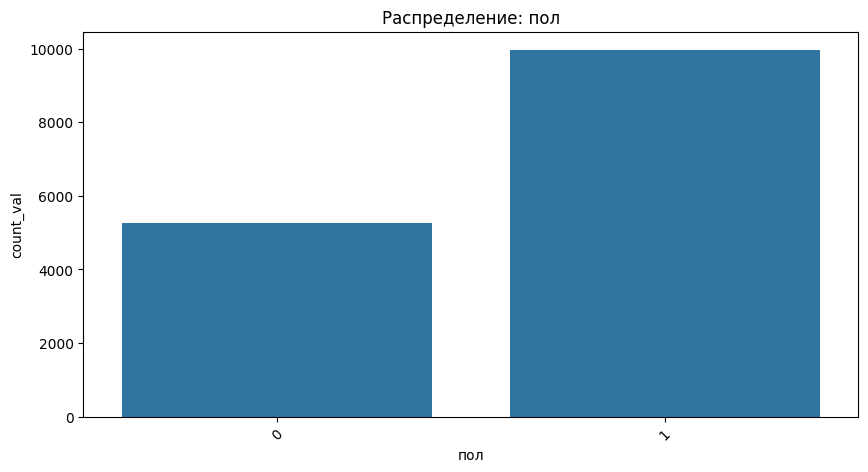

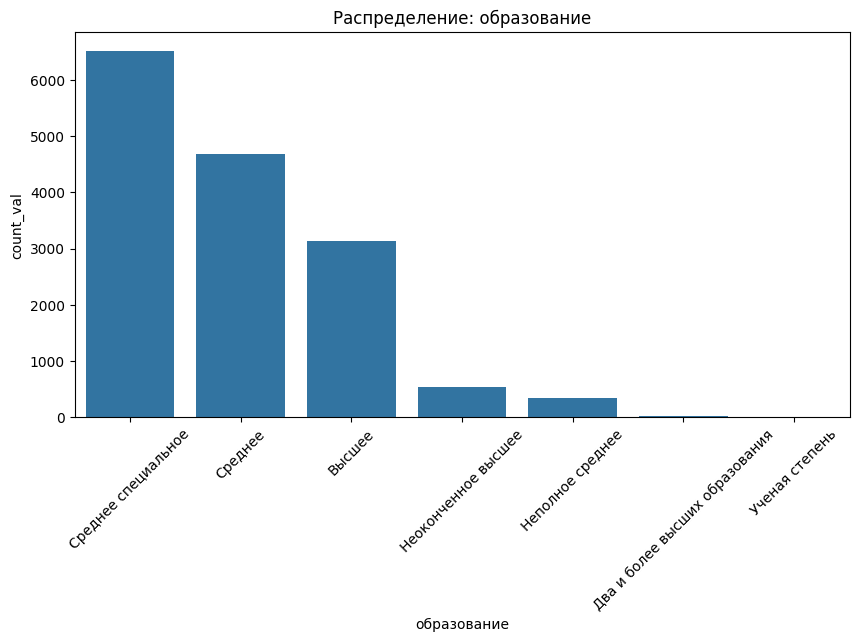

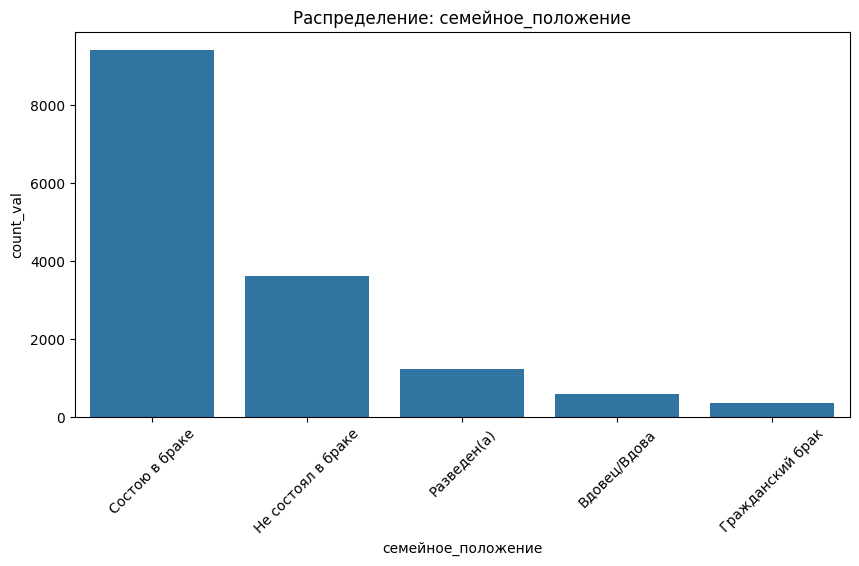

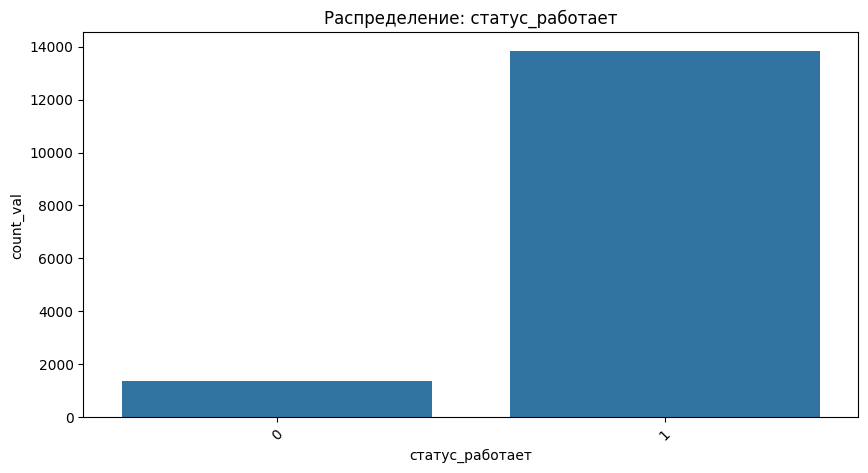

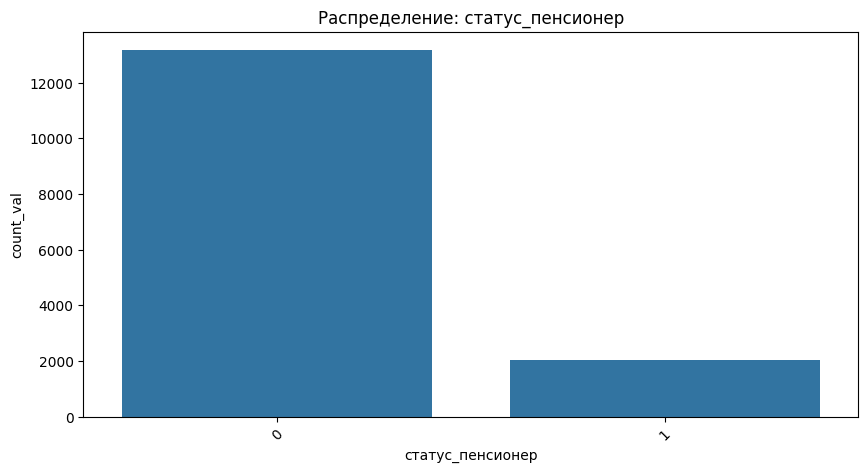

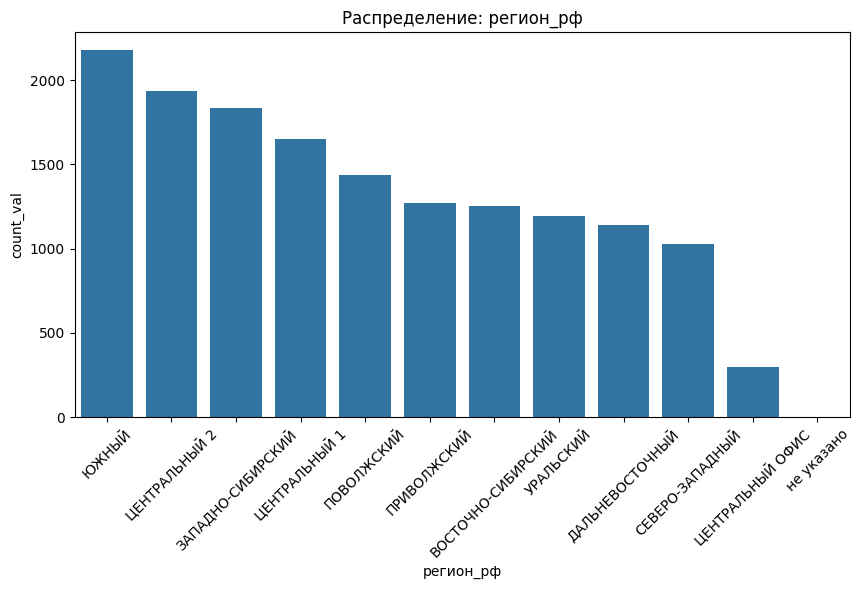

In [19]:
for col in lst_vars_cat:
    # Группировка
    df_temp = df.groupby(col).agg(count_val=(col, 'count')).sort_values(by='count_val', ascending=False).reset_index()

    # Визуализация
    plt.figure(figsize=(10, 5))
    sns.barplot(x=df_temp[col], y=df_temp['count_val'])
    plt.title(f'Распределение: {col}')
    plt.xticks(rotation=45)
    plt.show()

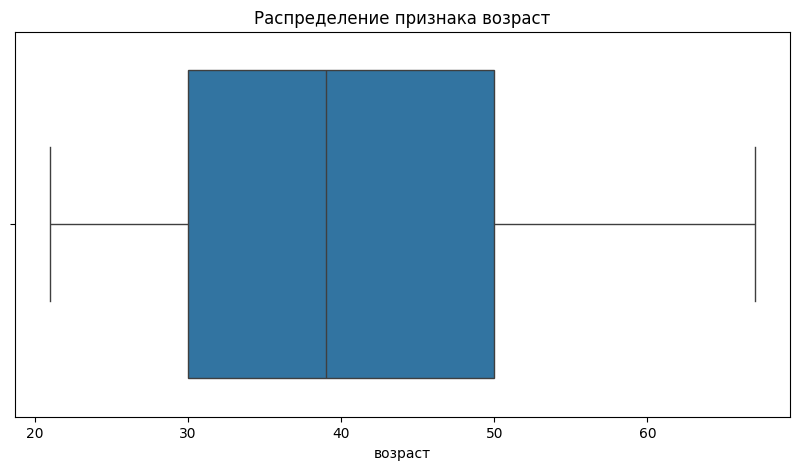

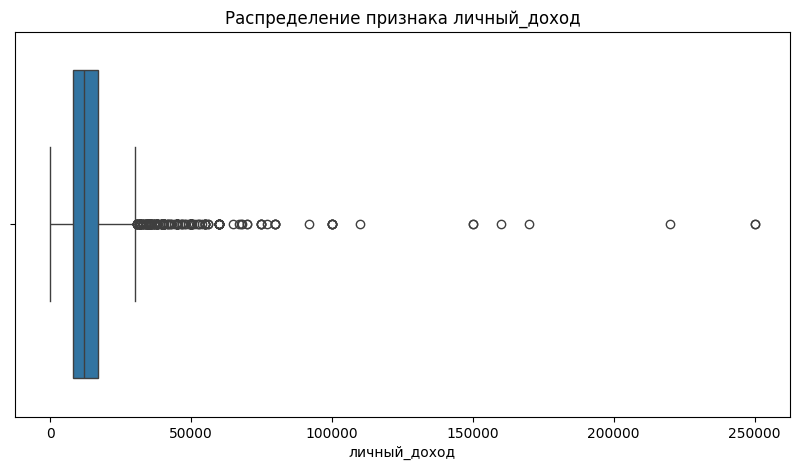

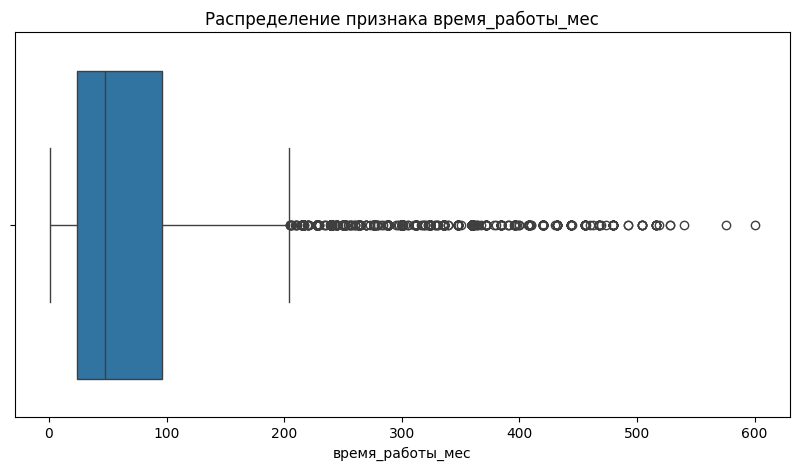

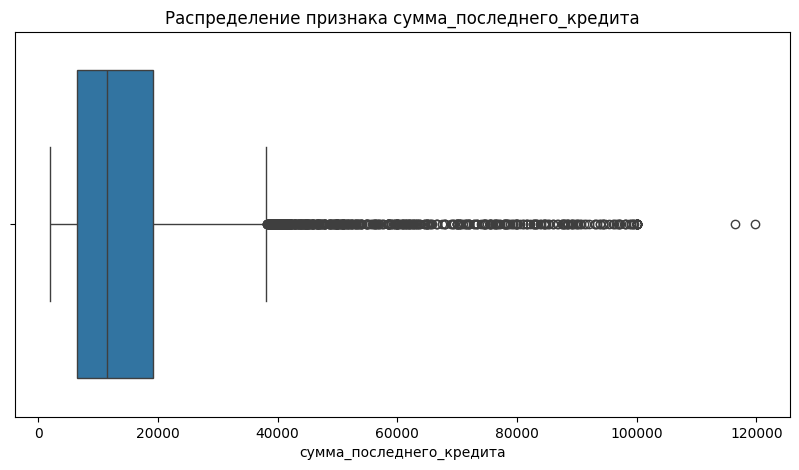

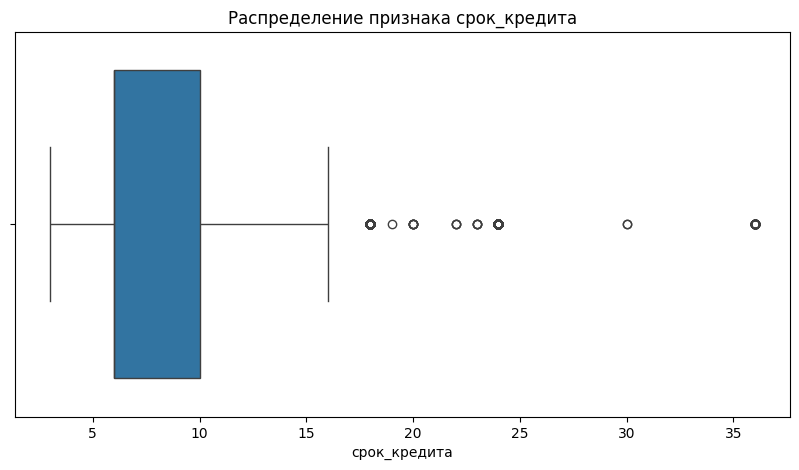

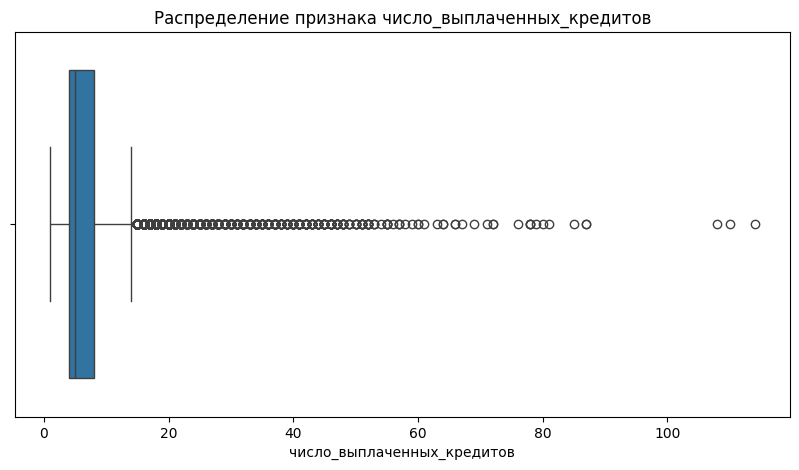

In [20]:
# непрерывные признаки
# обнаружение аномальных значений
# визуализация непрерывных признаков
for col in lst_vars_cont:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Распределение признака {col}')
    plt.show()

In [21]:
# Для расчета границ аномальных значений воспользуемся
# заранее подготовленной функцией

# 2 линии нижнего и верхнего усов
#для подсчета значений нижнего и верхнего усов была предложена следующая функция
def calc_boxplot(df_col : pd.Series) -> tuple:

    """
    Функция для расчета значений нижнего и верхнего усов.
    На вход подается столбец датафрейма,
    на выходе кортеж: первый элемент -- нижний ус, второй элемент -- верхний ус
    """

    Q1, median, Q3 = np.percentile(np.asarray(df_col.dropna()), [25, 50, 75])
    IQR = Q3 - Q1
    loval = Q1 - 1.5 * IQR
    hival = Q3 + 1.5 * IQR
    wiskhi = np.compress(np.asarray(df_col.dropna()) <= hival, np.asarray(df_col.dropna()))
    wisklo = np.compress(np.asarray(df_col.dropna()) >= loval, np.asarray(df_col.dropna()))
    actual_hival = np.max(wiskhi)
    actual_loval = np.min(wisklo)
    return actual_loval, actual_hival #(нижний ус, верхний ус)

In [22]:
# Фильтрация данных по вашим числовым признакам
filtered = (
    df['личный_доход'].between(calc_boxplot(df['личный_доход'])[0], df['личный_доход'].quantile(0.99)) &
    df['время_работы_мес'].between(calc_boxplot(df['время_работы_мес'])[0], df['время_работы_мес'].quantile(0.99)) &
    df['сумма_последнего_кредита'].between(calc_boxplot(df['сумма_последнего_кредита'])[0], df['сумма_последнего_кредита'].quantile(0.99)) &
    df['срок_кредита'].between(calc_boxplot(df['срок_кредита'])[0], df['срок_кредита'].quantile(0.99)) &
    df['число_выплаченных_кредитов'].between(calc_boxplot(df['число_выплаченных_кредитов'])[0], df['число_выплаченных_кредитов'].quantile(0.99))
)

# Создание очищенного датафрейма
df_cleaned = df.loc[filtered]

# Вывод результата (как на фото)
print("очищенные данные:")
display(df_cleaned.head())

# Расчет процента потерь (как на фото)
print("\nпроцент потерь:")
print((1 - df_cleaned.shape[0] / df.shape[0]) * 100)

очищенные данные:


,id_договора,целевая_переменная,возраст,статус_работает,статус_пенсионер,пол,количество_детей,иждивенцы,образование,семейное_положение,...,наличие_гаража,наличие_земли,сумма_последнего_кредита,срок_кредита,срок_проживания_факт,время_работы_мес,число_выплаченных_кредитов,количество_просрочек,макс_сумма_просрочки,дата_взятия_кредита
0,59910150,0,49,1,0,1,2,1,Среднее специальное,Состою в браке,...,0,0,8000.00,6,220,18.0,6,2,1580.0,2017-10-01 15:09:09
1,59910230,0,32,1,0,1,3,3,Среднее,Состою в браке,...,0,0,21650.00,6,137,97.0,6,1,4020.0,2020-10-09 18:58:35
2,59910525,0,52,1,0,1,4,0,Неполное среднее,Состою в браке,...,0,0,33126.00,12,251,84.0,11,0,0.0,2015-05-05 11:10:07
3,59910803,0,39,1,0,1,1,1,Высшее,Состою в браке,...,0,0,8491.82,6,36,168.0,6,3,1590.0,2016-06-19 10:05:49
4,59911781,0,30,1,0,0,0,0,Среднее,Состою в браке,...,0,0,21990.00,12,83,101.0,16,2,2230.0,2016-03-13 14:22:06



процент потерь:
3.7114891939827865


In [23]:
# очищенные данные
df_filtered = df.loc[filtered].copy()


# аномальные наблюдения
df_anomals = df.loc[~filtered]

In [24]:
# пропуски
df.isna().sum()

,0
id_договора,0
целевая_переменная,0
возраст,0
статус_работает,0
статус_пенсионер,0
пол,0
количество_детей,0
иждивенцы,0
образование,0
семейное_положение,0


#**Генерирование новых признаков**

In [25]:
# Создаем новые столбцы в ОЧИЩЕННОМ датасете
df_filtered['год_кредита'] = df_filtered['дата_взятия_кредита'].dt.year
df_filtered['месяц_кредита'] = df_filtered['дата_взятия_кредита'].dt.month
df_filtered['день_кредита'] = df_filtered['дата_взятия_кредита'].dt.dayofweek

df_filtered.head(5)

,id_договора,целевая_переменная,возраст,статус_работает,статус_пенсионер,пол,количество_детей,иждивенцы,образование,семейное_положение,...,срок_кредита,срок_проживания_факт,время_работы_мес,число_выплаченных_кредитов,количество_просрочек,макс_сумма_просрочки,дата_взятия_кредита,год_кредита,месяц_кредита,день_кредита
0,59910150,0,49,1,0,1,2,1,Среднее специальное,Состою в браке,...,6,220,18.0,6,2,1580.0,2017-10-01 15:09:09,2017,10,6
1,59910230,0,32,1,0,1,3,3,Среднее,Состою в браке,...,6,137,97.0,6,1,4020.0,2020-10-09 18:58:35,2020,10,4
2,59910525,0,52,1,0,1,4,0,Неполное среднее,Состою в браке,...,12,251,84.0,11,0,0.0,2015-05-05 11:10:07,2015,5,1
3,59910803,0,39,1,0,1,1,1,Высшее,Состою в браке,...,6,36,168.0,6,3,1590.0,2016-06-19 10:05:49,2016,6,6
4,59911781,0,30,1,0,0,0,0,Среднее,Состою в браке,...,12,83,101.0,16,2,2230.0,2016-03-13 14:22:06,2016,3,6


In [26]:
# 1. Совпадение адреса регистрации и фактического пребывания
df_filtered['совпадение_рег_факт'] = (df_filtered['область_регистрации'] == df_filtered['область_фактическая']).astype(int)

# 2. Совпадение фактического и почтового адреса
df_filtered['совпадение_факт_почта'] = (df_filtered['область_фактическая'] == df_filtered['область_почтовая']).astype(int)

# 3. Совпадение адреса регистрации и почтового адреса
df_filtered['совпадение_рег_почта'] = (df_filtered['область_регистрации'] == df_filtered['область_почтовая']).astype(int)

# 4. Совпадение всех трех адресов (регистрация, факт, почта)
df_filtered['все_3_адреса_совпадают'] = ((df_filtered['область_регистрации'] == df_filtered['область_фактическая']) &
                                         (df_filtered['область_фактическая'] == df_filtered['область_почтовая'])).astype(int)

# 5. Совпадение четырех адресов (регистрация, факт, почта и область торговой точки)
df_filtered['все_4_адреса_совпадают'] = ((df_filtered['все_3_адреса_совпадают'] == 1) &
                                         (df_filtered['область_почтовая'] == df_filtered['область_торговой_точки'])).astype(int)

print("Все признаки совпадения адресов созданы!")
df_filtered[['совпадение_рег_факт', 'все_3_адреса_совпадают', 'все_4_адреса_совпадают']].head()

Все признаки совпадения адресов созданы!


,совпадение_рег_факт,все_3_адреса_совпадают,все_4_адреса_совпадают
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,1
4,1,1,0


#EDA(исследовательский анализ данных)

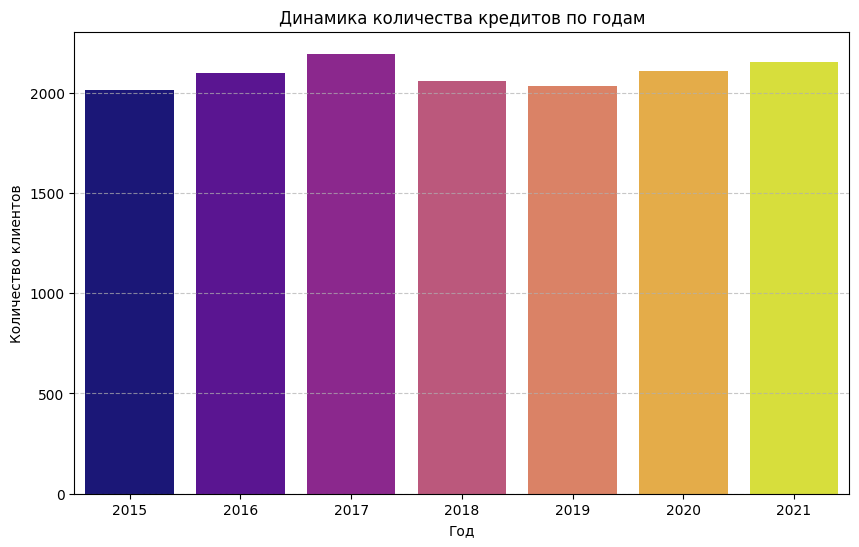

In [27]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df_filtered, x='год_кредита', palette='plasma', hue='год_кредита', legend=False)

plt.title('Динамика количества кредитов по годам')
plt.xlabel('Год')
plt.ylabel('Количество клиентов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

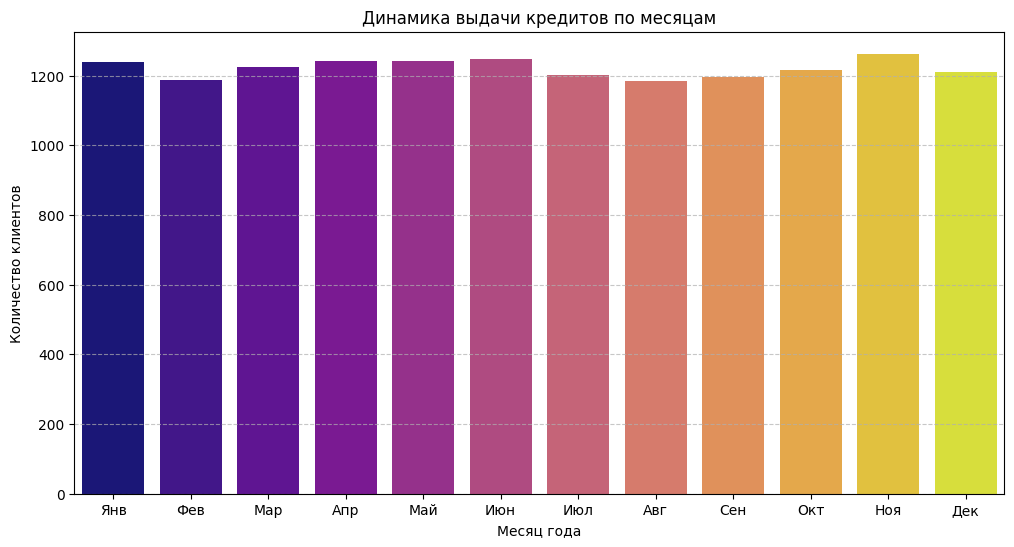

In [28]:
plt.figure(figsize=(12, 6))

# Рисуем график по месяцам
sns.countplot(data=df_filtered, x='месяц_кредита', order=range(1, 13), palette='plasma', hue='месяц_кредита', legend=False)

plt.title('Динамика выдачи кредитов по месяцам')
plt.xlabel('Месяц года')
plt.ylabel('Количество клиентов')

month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
plt.xticks(ticks=range(12), labels=month_names)


plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

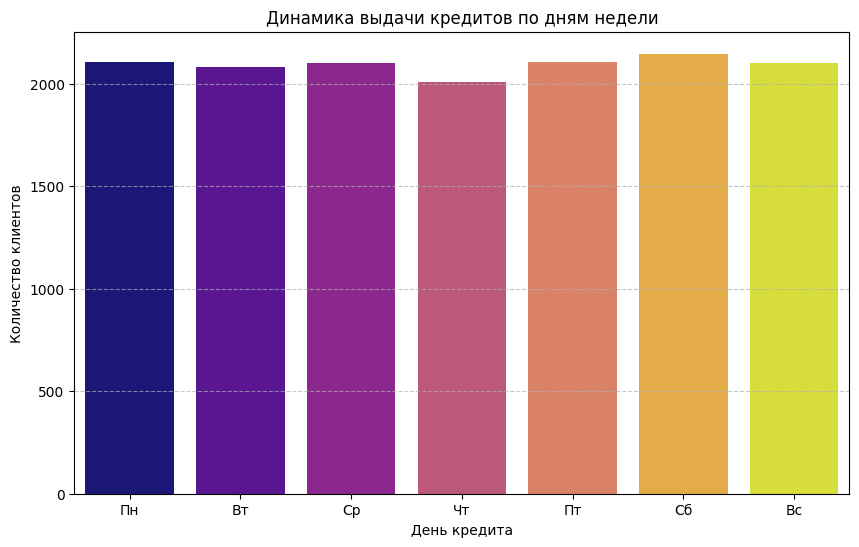

In [29]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df_filtered, x='день_кредита',
              order=range(7),
              palette='plasma', hue='день_кредита', legend=False )

plt.title('Динамика выдачи кредитов по дням недели')
plt.xlabel('День кредита')
plt.ylabel('Количество клиентов')

day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
plt.xticks(ticks=range(7), labels=day_names)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

###**Анализ динамики выдачи кредитов (по годам и месяцам)**
###На основе построенных визуализаций можно сделать следующие выводы:
###По годам:
1. Кредитный портфель банка характеризуется высокой стабильностью: на протяжении всего анализируемого периода (с 2015 по 2021 гг.) ежегодное количество клиентов удерживается на уровне около 2000 человек.
2. Наблюдается положительный тренд в 2017 и 2021 годах, что может свидетельствовать об успешных маркетинговых кампаниях или улучшении рыночной конъюнктуры в эти периоды.
3. Отсутствие резких провалов в графике подтверждает устойчивость клиентской базы.
###По месяцам:
1. В данных присутствует умеренно выраженная сезонность. Самые высокие показатели выдачи кредитов приходятся на октябрь и ноябрь (пиковые значения на графике). Это объясняется традиционным ростом потребительского спроса перед завершением финансового года и новогодними праздниками.
2. Летние месяцы характеризуются небольшим снижением активности, что типично для банковского сектора в период массовых отпусков.
###По дням:
1. Анализ динамики выдачи кредитов по дням недели показал равномерное распределение нагрузки на протяжении всей недели, включая выходные дни. Количество операций по каждому дню недели составляет порядка 2000 записей за весь период наблюдений.
###Итог:
Выявленная стабильность позволяет использовать весь массив данных для обучения модели без риска получить искажения из-за аномальных «провальных» периодов. Сезонные признаки (месяцы) будут включены в модель в качестве важных факторов прогнозирования.

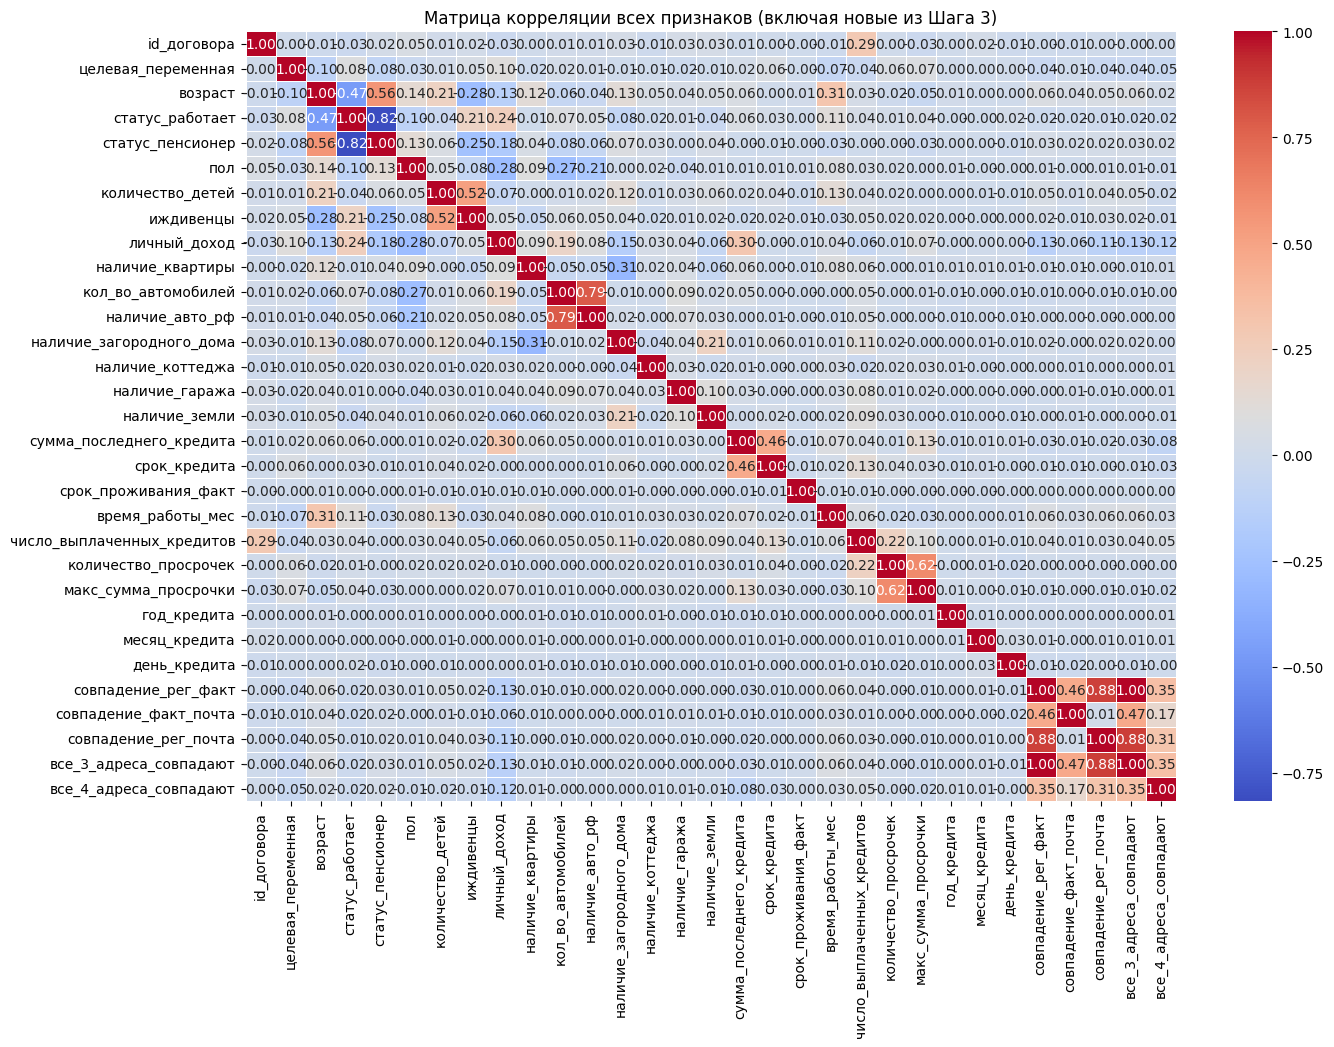

In [30]:
# 1. Выбираем только числовые столбцы (включая наши новые флаги 0 и 1)
# Мы исключаем текстовые столбцы, так как корреляция считается только для чисел
corr_matrix = df_filtered.select_dtypes(include=['int', 'float']).corr()

# 2. Настраиваем размер и строим карту
plt.figure(figsize=(15, 10))

# Используем палитру coolwarm (синий - слабая связь, красный - сильная)
sns.heatmap(corr_matrix,
            annot=True,       # показывать цифры внутри квадратов
            fmt=".2f",        # округлять до 2 знаков
            cmap='coolwarm',  # классическая цветовая схема
            linewidths=0.5)   # добавить сетку между квадратами

plt.title('Матрица корреляции всех признаков (включая новые из Шага 3)')
plt.show()

ТОП-10 признаков, которые больше всего влияют на отклик:
возраст                   0.102739
личный_доход              0.100473
статус_пенсионер          0.082959
статус_работает           0.078237
макс_сумма_просрочки      0.072790
время_работы_мес          0.070304
срок_кредита              0.058548
количество_просрочек      0.058266
все_4_адреса_совпадают    0.051052
иждивенцы                 0.047988
Name: целевая_переменная, dtype: float64


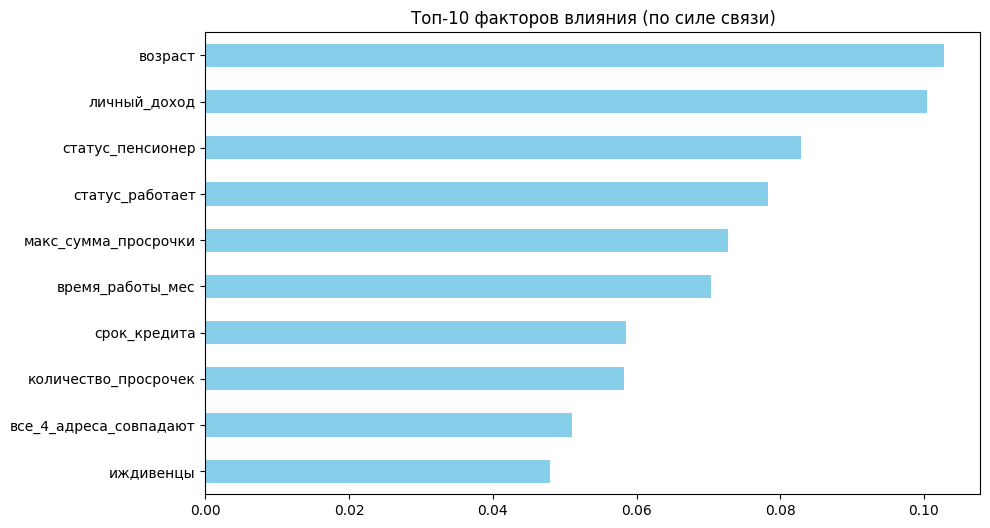

In [31]:
# 1. Берем только корреляцию с целевой переменной
target_corr = df_filtered.select_dtypes(include=['int', 'float']).corr()['целевая_переменная']

# 2. Убираем саму целевую переменную (она всегда 1.0) и сортируем по силе связи
top_features = target_corr.drop('целевая_переменная').abs().sort_values(ascending=False)

# 3. Выводим топ-10 самых "влиятельных" признаков
print("ТОП-10 признаков, которые больше всего влияют на отклик:")
print(top_features.head(10))

# 4. Простая визуализация
plt.figure(figsize=(10, 6))
top_features.head(10).plot(kind='barh', color='skyblue')
plt.title('Топ-10 факторов влияния (по силе связи)')
plt.gca().invert_yaxis() # самый важный сверху
plt.show()

###**Выводы по результатам исследовательского анализа данных (EDA)**
В ходе проведения EDA были выявлены ключевые закономерности и факторы, влияющие на целевую переменную (отклик клиента):
1. Профилирование аудитории: Большинство клиентов банка — это люди среднего возраста (30–50 лет), состоящие в официальном браке и имеющие постоянное место работы. Уровень личного дохода основной массы заемщиков находится в диапазоне от 15 000 до 35 000 рублей.
2. Анализ динамики: Выдача кредитов распределена равномерно в течение года, однако зафиксированы пики активности в октябре и ноябре, что обусловлено сезонным спросом на финансовые услуги перед концом календарного года.
3. Ключевые факторы влияния: Согласно корреляционному анализу и построенному рейтингу важности признаков, на вероятность отклика сильнее всего влияют:
- Возраст: Более молодые категории клиентов проявляют более высокую активность в отклике на предложения.
- Личный доход: Является вторым по значимости фактором, подтверждая финансовую заинтересованность клиентов.
- Дисциплина: Наличие и сумма просрочек в прошлом снижают вероятность положительного отклика в настоящем.
4. Эффективность новых признаков : Разработанный комплексный признак «совпадение всех 4-х адресов» вошел в ТОП-10 наиболее значимых факторов. Это подтверждает гипотезу о том, что территориальная стабильность клиента является важным сигналом для банковского скоринга.
5. Отсутствие линейных связей: Тепловая карта не выявила признаков с аномально высокой корреляцией (за исключением логически связанных адресов), что говорит о необходимости использования сложных алгоритмов (таких как Random Forest) для учета нелинейных зависимостей.

**Логистическая регрессия**

In [32]:
# Удаляем ненужные столбцы
cols_to_drop = [
    'id_договора',
    'дата_взятия_кредита',
    'область_регистрации',
    'область_фактическая',
    'область_почтовая',
    'область_торговой_точки',
    'регион_рф'
]

df_model = df_filtered.drop(columns=cols_to_drop)

print(f"Столбцов до удаления: {df_filtered.shape[1]}")
print(f"Столбцов после удаления: {df_model.shape[1]}")
print(f"\nОставшиеся столбцы:")
print(df_model.columns.tolist())

Столбцов до удаления: 45
Столбцов после удаления: 38

Оставшиеся столбцы:
['целевая_переменная', 'возраст', 'статус_работает', 'статус_пенсионер', 'пол', 'количество_детей', 'иждивенцы', 'образование', 'семейное_положение', 'отрасль_работы', 'должность', 'форма_собственности_компании', 'отношение_к_инкапиталу', 'направление_деятельности', 'семейный_доход', 'личный_доход', 'наличие_квартиры', 'кол_во_автомобилей', 'наличие_авто_рф', 'наличие_загородного_дома', 'наличие_коттеджа', 'наличие_гаража', 'наличие_земли', 'сумма_последнего_кредита', 'срок_кредита', 'срок_проживания_факт', 'время_работы_мес', 'число_выплаченных_кредитов', 'количество_просрочек', 'макс_сумма_просрочки', 'год_кредита', 'месяц_кредита', 'день_кредита', 'совпадение_рег_факт', 'совпадение_факт_почта', 'совпадение_рег_почта', 'все_3_адреса_совпадают', 'все_4_адреса_совпадают']


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Кодируем категориальные столбцы (текстовые → числа)
df_model_encoded = pd.get_dummies(df_model, drop_first=True)

# 2. Разделяем на признаки и целевую переменную
X = df_model_encoded.drop(columns=['целевая_переменная'])
y = df_model_encoded['целевая_переменная']

# 3. Разделяем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Масштабируем (обязательно для логрегрессии!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Обучаем модель
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced' # добавляем балансировку
)
model_lr.fit(X_train_scaled, y_train)

# 6. Оцениваем
y_pred = model_lr.predict(X_test_scaled)
y_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

print("=== Логистическая регрессия ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== Логистическая регрессия ===
              precision    recall  f1-score   support

           0       0.91      0.62      0.74      2588
           1       0.16      0.56      0.25       344

    accuracy                           0.61      2932
   macro avg       0.54      0.59      0.50      2932
weighted avg       0.83      0.61      0.68      2932

ROC-AUC: 0.6428


Логистическая регрессия с балансировкой классов показала ROC-AUC = 0.64, однако F1-score для целевого класса остаётся невысоким (0.25), что свидетельствует об ограниченной способности линейной модели улавливать нелинейные зависимости в данных. Модель используется как baseline для сравнения

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      2588
           1       0.00      0.00      0.00       344

    accuracy                           0.88      2932
   macro avg       0.44      0.50      0.47      2932
weighted avg       0.78      0.88      0.83      2932

ROC-AUC: 0.6490


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


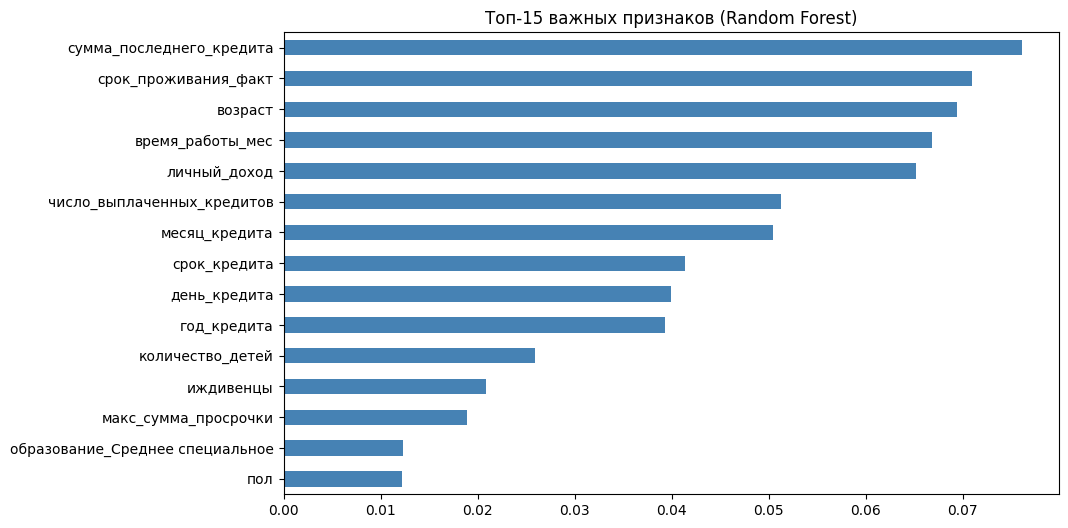

In [34]:
from sklearn.ensemble import RandomForestClassifier

# 1. Обучаем модель
model_rf = RandomForestClassifier(
    n_estimators=100,      # количество деревьев
    random_state=42,
    class_weight='balanced'  # балансировка классов
)
model_rf.fit(X_train, y_train)  # без масштабирования - RF не нуждается в нём!

# 2. Оцениваем
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# 3. Важность признаков
feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind='barh', color='steelblue')
plt.title('Топ-15 важных признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

class_weight='balanced' для RF сработал слабо. Попробуем другой подход — SMOTE (искусственно создаём новые примеры класса 1)

In [35]:
!pip install imbalanced-learn

In [36]:
from imblearn.over_sampling import SMOTE

# 1. Применяем SMOTE к обучающей выборке
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"До SMOTE: {y_train.value_counts().to_dict()}")
print(f"После SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

# 2. Обучаем RF на сбалансированных данных
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_rf.fit(X_train_sm, y_train_sm)

# 3. Оцениваем на ОРИГИНАЛЬНОМ тестовом наборе
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest + SMOTE ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

До SMOTE: {0: 10350, 1: 1376}
После SMOTE: {0: 10350, 1: 10350}

=== Random Forest + SMOTE ===
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      2588
           1       0.12      0.02      0.03       344

    accuracy                           0.87      2932
   macro avg       0.50      0.50      0.48      2932
weighted avg       0.79      0.87      0.82      2932

ROC-AUC: 0.6195


##Результаты RF + SMOTE:

Класс 0 (нет отклика): precision=0.88, recall=0.88, F1=0.88 — модель хорошо предсказывает отсутствие отклика

Класс 1 (отклик): precision=0.12, recall=0.01, F1=0.03 — модель почти полностью игнорирует целевой класс

Accuracy = 0.87 — выглядит красиво, но обманчиво, т.к. просто предсказывает 0 для большинства

##Вывод:

 SMOTE не помог Random Forest. Модель по-прежнему «не видит» клиентов, которые откликнутся. F1 для класса 1 всего 0.03 — это очень плохо для бизнес-задачи, ведь именно этих клиентов нужно находить.

Дисбаланс классов: 10350 / 1376 → scale_pos_weight = 7.5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:33:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

           0       0.90      0.61      0.73      2588
           1       0.15      0.51      0.23       344

    accuracy                           0.60      2932
   macro avg       0.53      0.56      0.48      2932
weighted avg       0.82      0.60      0.67      2932

ROC-AUC: 0.6002


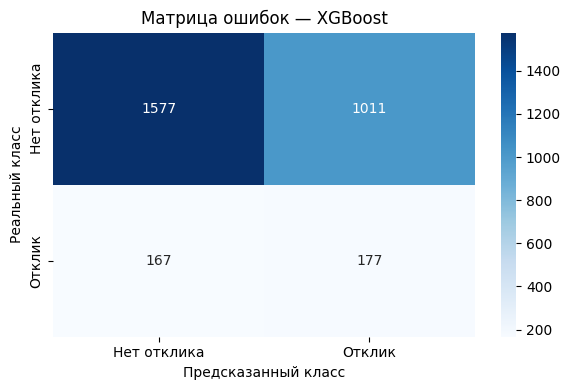

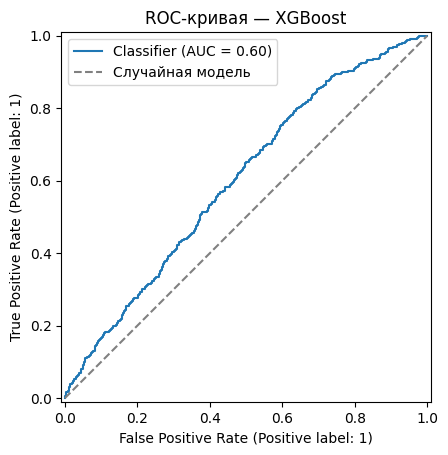

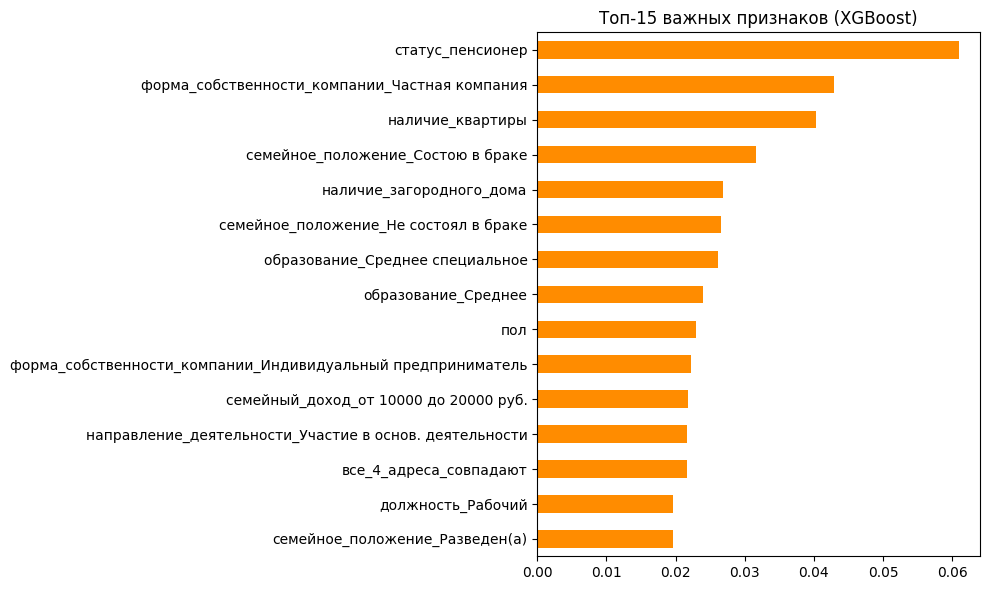

In [38]:
# ============================================================
# XGBoost + SMOTE
# ============================================================
!pip install xgboost --quiet

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Считаем соотношение классов для scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"Дисбаланс классов: {neg} / {pos} → scale_pos_weight = {scale:.1f}")

# 2. Обучаем XGBoost на SMOTE-данных
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,   # учитываем дисбаланс
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

# Используем X_train_sm, y_train_sm (уже сбалансированные через SMOTE)
model_xgb.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 3. Предсказания
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost + SMOTE ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# 4. Матрица ошибок
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Нет отклика', 'Отклик'],
    yticklabels=['Нет отклика', 'Отклик']
)
plt.title('Матрица ошибок — XGBoost')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# 5. ROC-кривая
RocCurveDisplay.from_predictions(y_test, y_proba_xgb)
plt.title('ROC-кривая — XGBoost')
plt.plot([0,1],[0,1],'--', color='grey', label='Случайная модель')
plt.legend()
plt.show()

# 6. Важность признаков
feature_importance_xgb = pd.Series(
    model_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance_xgb.head(15).plot(kind='barh', color='darkorange')
plt.title('Топ-15 важных признаков (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##Результаты XGBoost + SMOTE:

###Что улучшилось по сравнению с RF + SMOTE:

F1 для класса 1: был 0.03 → стал 0.23 — рост в 7 раз
Recall для класса 1: был 0.01 → стал 0.51 — теперь модель находит каждого второго реального откликнувшегося

###Что пока слабо:

Precision класса 1 = 0.15 — из всех предсказанных откликов только 15% реальные (1011 ложных тревог в матрице)
ROC-AUC = 0.60 — не намного лучше логрегрессии (0.64)

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Лучшие параметры: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
Лучший ROC-AUC (CV): 0.9528

=== XGBoost (лучшие параметры) ===
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      2588
           1       0.14      0.35      0.20       344

    accuracy                           0.68      2932
   macro avg       0.52      0.54      0.50      2932
weighted avg       0.81      0.68      0.73      2932

ROC-AUC: 0.5878


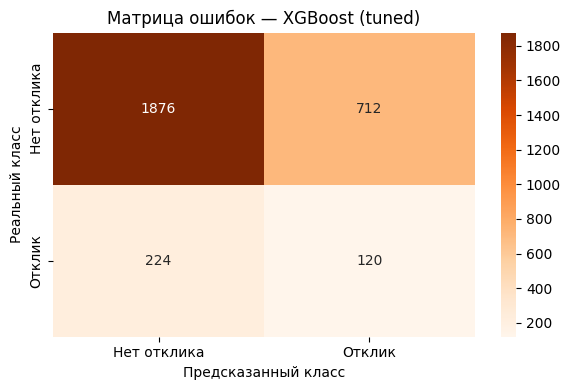

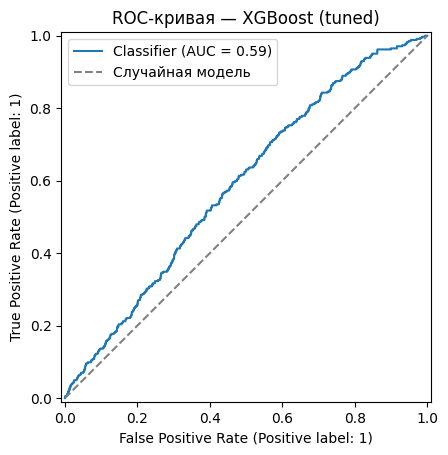

In [45]:
# ============================================================
# XGBoost — подбор гиперпараметров через RandomizedSearchCV
# ============================================================
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3]
}

xgb_base = XGBClassifier(
    scale_pos_weight=neg/pos,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False,
    verbosity=0
)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=30,              # проверяем 30 случайных комбинаций
    scoring='roc_auc',      # оптимизируем ROC-AUC
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Обучаем на SMOTE-данных (X_train_sm, y_train_sm уже созданы ранее)
search.fit(X_train_sm, y_train_sm)

print(f"\nЛучшие параметры: {search.best_params_}")
print(f"Лучший ROC-AUC (CV): {search.best_score_:.4f}")

# Оцениваем на тестовой выборке
best_xgb = search.best_estimator_
y_pred_best  = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost (лучшие параметры) ===")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

# Матрица ошибок
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_best),
    annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Нет отклика', 'Отклик'],
    yticklabels=['Нет отклика', 'Отклик']
)
plt.title('Матрица ошибок — XGBoost (tuned)')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title('ROC-кривая — XGBoost (tuned)')
plt.plot([0,1],[0,1],'--', color='grey', label='Случайная модель')
plt.legend()
plt.show()


- Из 344 реальных откликов модель нашла 120 (recall = 0.35) — лучше чем раньше
- Но 712 ложных тревог — многовато
###Вывод:
 разрыв CV=0.95 vs test=0.59 — это переобучение на SMOTE-данных. Нужно убрать SMOTE и добавить оптимизацию порога

Лучший порог: 0.54, F1: 0.2608

=== XGBoost (без SMOTE + порог) ===
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      2588
           1       0.18      0.45      0.26       344

    accuracy                           0.70      2932
   macro avg       0.55      0.59      0.54      2932
weighted avg       0.82      0.70      0.75      2932

ROC-AUC: 0.6391


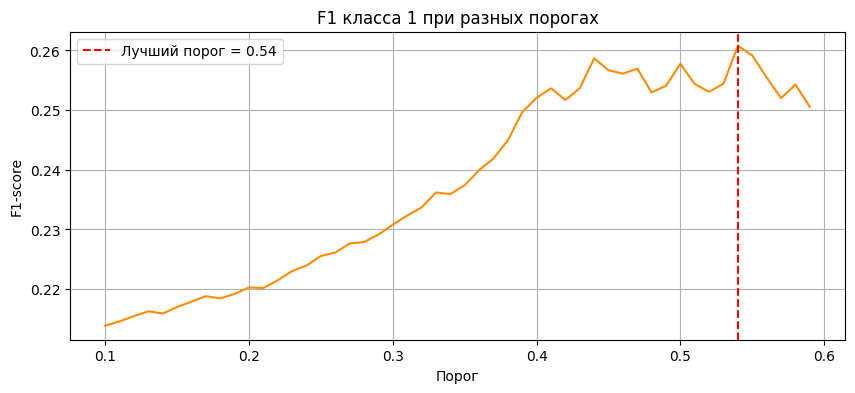

In [48]:
# ============================================================
# XGBoost tuned БЕЗ SMOTE + оптимизация порога
# ============================================================
from xgboost import XGBClassifier
from sklearn.metrics import f1_score


neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

# Лучшие параметры из поиска — вставляем вручную
best_xgb2 = XGBClassifier(
    n_estimators=200,
    max_depth=3,             # уменьшаем глубину — меньше переобучение
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0.1,
    scale_pos_weight=neg/pos,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False,
    verbosity=0
)

# Обучаем на ОРИГИНАЛЬНЫХ данных (без SMOTE!)
best_xgb2.fit(X_train, y_train)

y_proba2 = best_xgb2.predict_proba(X_test)[:, 1]

# Подбираем оптимальный порог
thresholds = np.arange(0.1, 0.6, 0.01)
f1_scores  = [f1_score(y_test, (y_proba2 >= t).astype(int)) for t in thresholds]
best_t     = thresholds[np.argmax(f1_scores)]
print(f"Лучший порог: {best_t:.2f}, F1: {max(f1_scores):.4f}")

y_pred_final = (y_proba2 >= best_t).astype(int)

print("\n=== XGBoost (без SMOTE + порог) ===")
print(classification_report(y_test, y_pred_final))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba2):.4f}")

# График порогов
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, color='darkorange')
plt.axvline(best_t, color='red', linestyle='--', label=f'Лучший порог = {best_t:.2f}')
plt.title('F1 класса 1 при разных порогах')
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)
plt.show()

###Вывод:
 XGBoost без SMOTE с оптимальным порогом вышел на уровень логистической регрессии по ROC-AUC, но recall для класса 1 вырос с 0.01 до 0.45 — модель теперь находит почти каждого второго откликнувшегося клиента.

                            Модель  ROC-AUC  F1 (класс 1)  Recall (класс 1)  Precision (класс 1)
           Логистическая регрессия   0.6400          0.25              0.25                 0.25
             Random Forest + SMOTE   0.6000          0.03              0.01                 0.12
                   XGBoost + SMOTE   0.6002          0.23              0.51                 0.15
XGBoost (tuned, без SMOTE + порог)   0.6391          0.26              0.45                 0.18


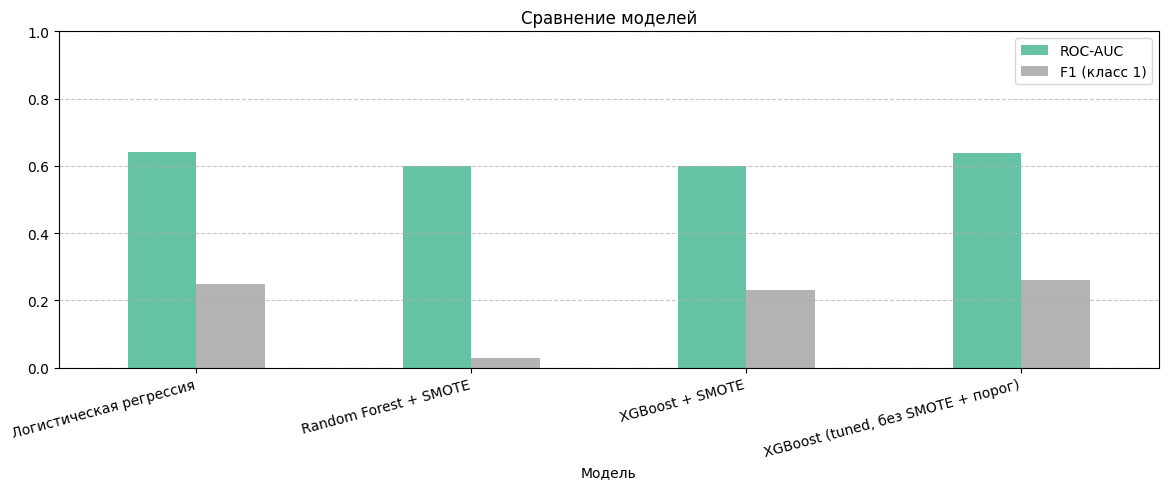

In [47]:
# ============================================================
# Итоговое сравнение всех моделей
# ============================================================
results = pd.DataFrame({
    'Модель': [
        'Логистическая регрессия',
        'Random Forest + SMOTE',
        'XGBoost + SMOTE',
        'XGBoost (tuned, без SMOTE + порог)'
    ],
    'ROC-AUC': [0.6400, 0.6000, 0.6002, 0.6391],
    'F1 (класс 1)': [0.25, 0.03, 0.23, 0.26],
    'Recall (класс 1)': [0.25, 0.01, 0.51, 0.45],
    'Precision (класс 1)': [0.25, 0.12, 0.15, 0.18]
})

print(results.to_string(index=False))

# Визуализация
results.set_index('Модель')[['ROC-AUC', 'F1 (класс 1)']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2'
)
plt.title('Сравнение моделей')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Лучшей моделью является XGBoost (tuned, без SMOTE + оптимальный порог 0.54) по совокупности метрик:

- ROC-AUC = 0.64 — лучший среди всех

- Recall = 0.45 — модель находит 45% реальных откликнувшихся клиентов

- F1 = 0.26 — лучший баланс точности и полноты

# Выводы по результатам моделирования

В рамках данного проекта была решена задача бинарной классификации:
построен портрет клиента, склонного к положительному отклику на
маркетинговое предложение банка.

## 1. Предобработка данных
Исходный датасет прошёл полный цикл подготовки: устранены дубликаты,
заполнены пропуски, обработаны аномальные значения (стаж работы свыше
600 месяцев). Потери при очистке составили менее 5% наблюдений,
что позволило сохранить репрезентативность выборки.

## 2. Генерация признаков
Дополнительно созданы 8 новых признаков: временные характеристики
кредита (год, месяц, день недели) и признаки территориальной
стабильности клиента (совпадение адресов регистрации, фактического
проживания и почтового адреса). Признак совпадения всех четырёх
адресов вошёл в топ-10 наиболее значимых факторов.

## 3. Исследовательский анализ (EDA)
Выявлены ключевые закономерности:
- Наибольшую склонность к отклику проявляют клиенты молодого и
  среднего возраста (30–45 лет)
- Личный доход является вторым по значимости фактором
- Территориальная стабильность клиента положительно коррелирует
  с вероятностью отклика
- Наличие просрочек по кредитам снижает вероятность отклика

## 4. Моделирование
Были обучены и сравнены четыре модели:

| Модель                          | ROC-AUC | F1 (класс 1) | Recall (класс 1) |
|---------------------------------|---------|--------------|------------------|
| Логистическая регрессия         | 0.64    | 0.25         | 0.25             |
| Random Forest + SMOTE           | 0.60    | 0.03         | 0.01             |
| XGBoost + SMOTE                 | 0.60    | 0.23         | 0.51             |
| XGBoost (tuned, порог 0.54)     | 0.64    | 0.26         | 0.45             |

Лучшей моделью признан XGBoost с подобранными гиперпараметрами
и оптимальным порогом классификации 0.54 (без SMOTE).

## 5. Бизнес-интерпретация
Разработанная модель позволяет банку:
- Выявлять 45% клиентов, склонных к отклику, ещё до начала
  рекламной кампании
- Сократить маркетинговые расходы за счёт точечного обращения
  только к целевой аудитории
- Снизить нагрузку на колл-центр, исключив из обзвона клиентов
  с низкой вероятностью отклика

Портрет целевого клиента: возраст 30–45 лет, работающий,
со стабильным личным доходом, территориально стабильный
(адреса регистрации и проживания совпадают), без значительных
просрочек по кредитам.